<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/mini_batch_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Weight: -1.4153707420504142
Initial Bias: -0.42064532276535904
Epoch   1 | Loss: 529.7329
Epoch   2 | Loss: 133.6672
Epoch   3 | Loss: 38.3446
Epoch   4 | Loss: 15.1138
Epoch   5 | Loss: 9.5876
Epoch   6 | Loss: 8.1698
Epoch   7 | Loss: 7.8082
Epoch   8 | Loss: 7.6705
Epoch   9 | Loss: 7.6236
Epoch  10 | Loss: 7.5722
Epoch  11 | Loss: 7.5378
Epoch  12 | Loss: 7.5194
Epoch  13 | Loss: 7.4318
Epoch  14 | Loss: 7.3957
Epoch  15 | Loss: 7.3553
Epoch  16 | Loss: 7.3182
Epoch  17 | Loss: 7.2709
Epoch  18 | Loss: 7.2588
Epoch  19 | Loss: 7.2200
Epoch  20 | Loss: 7.1567
Epoch  21 | Loss: 7.1786
Epoch  22 | Loss: 7.1228
Epoch  23 | Loss: 7.0517
Epoch  24 | Loss: 7.0177
Epoch  25 | Loss: 6.9726
Epoch  26 | Loss: 6.9269
Epoch  27 | Loss: 6.9199
Epoch  28 | Loss: 6.8571
Epoch  29 | Loss: 6.8411
Epoch  30 | Loss: 6.8505
Epoch  31 | Loss: 6.7555
Epoch  32 | Loss: 6.7235
Epoch  33 | Loss: 6.6857
Epoch  34 | Loss: 6.6663
Epoch  35 | Loss: 6.6383
Epoch  36 | Loss: 6.6234
Epoch  37 | Loss: 6.567

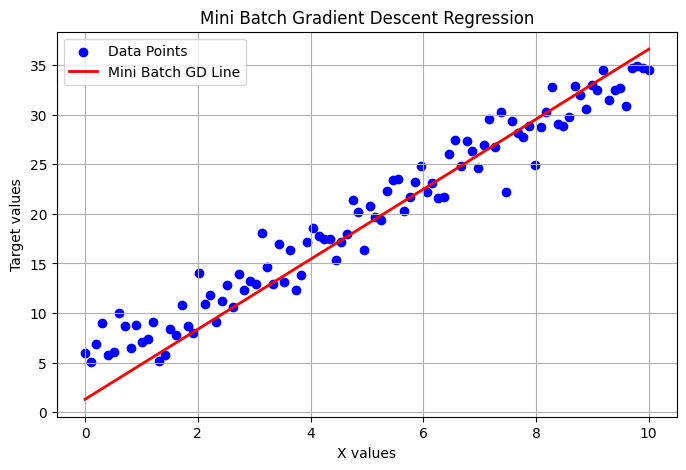

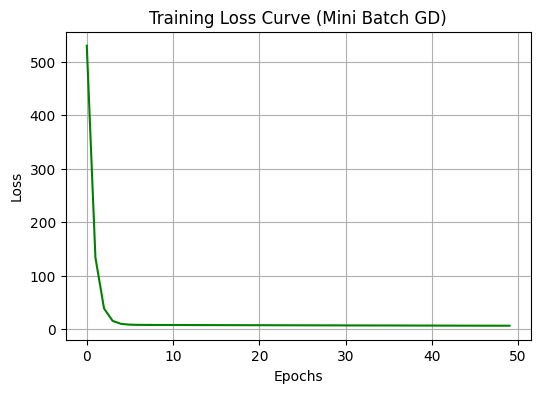

In [1]:
############
#
# Mini Batch Gradient Descent
# (Deep Learning Training Example)
#
############

### Import libraries
import numpy as np
import matplotlib.pyplot as plt

### Create dataset
np.random.seed(42)

X = np.linspace(0,10,100)
y = 3*X + 5 + np.random.randn(100)*2

X = X.reshape(-1,1)
y = y.reshape(-1,1)

### Hyperparameters
learning_rate = 0.001
epochs = 50
batch_size = 10

### Initialize weights randomly
weights = np.random.randn(1,1)
bias = np.random.randn(1)

print("Initial Weight:", weights[0][0])
print("Initial Bias:", bias[0])

### Store loss values
loss_history = []

### Training using Mini Batch Gradient Descent
for epoch in range(epochs):

    total_loss = 0

    # shuffle dataset each epoch
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # process mini batches
    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # prediction
        y_pred = np.dot(X_batch, weights) + bias

        # error
        error = y_batch - y_pred

        # loss
        loss = np.mean(error**2)
        total_loss += loss

        # gradients
        dW = -2 * np.dot(X_batch.T, error) / len(X_batch)
        dB = -2 * np.mean(error)

        # update weights
        weights = weights - learning_rate * dW
        bias = bias - learning_rate * dB

    avg_loss = total_loss / (len(X)/batch_size)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")

print("\nTraining Complete")
print("Final Weight:", weights[0][0])
print("Final Bias:", bias[0])

### Predictions
y_pred_all = np.dot(X, weights) + bias

### Plot regression result
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', label="Data Points")
plt.plot(X, y_pred_all, color='red', linewidth=2, label="Mini Batch GD Line")

plt.xlabel("X values")
plt.ylabel("Target values")
plt.title("Mini Batch Gradient Descent Regression")
plt.legend()
plt.grid(True)

plt.show()

### Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history, color='green')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Mini Batch GD)")
plt.grid(True)
plt.show()